# Montar el entorno de drive

In [7]:
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Instalar librerías necesarias
!pip install ultralytics roboflow anvil-uplink ffmpeg-python -q

import torch
import os

# Verificar GPU
if torch.cuda.is_available():
    device_properties = torch.cuda.get_device_properties(0)
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
    print(f'Memoria GPU: {device_properties.total_memory / 1e9:.1f} GB')
else:
    print('No hay GPU disponible. Ve a Entorno de ejecución > Cambiar tipo de entorno > T4 GPU')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.5/124.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.7 MB/s eta 0:00:00
No hay GPU disponible. Ve a Entorno de ejecución > Cambiar tipo de entorno > T4 GPU


# Montar rutas para el drive

In [ ]:
# Definir rutas en tu Drive
DRIVE_PATH = '/content/drive/MyDrive/Driver_Behaviour_Project_2'
if not os.path.exists(DRIVE_PATH):
    os.makedirs(DRIVE_PATH)
    print(f"Carpeta creada en: {DRIVE_PATH}")

# Ruta para guardar los pesos del modelo entrenado
WEIGHTS_DESTINATION = os.path.join(DRIVE_PATH, 'weights')
if not os.path.exists(WEIGHTS_DESTINATION):
    os.makedirs(WEIGHTS_DESTINATION)

# Importar dataset

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="yxf6ArlOA5Yxvo5uE1Ty")
project = rf.workspace("driver-miviz").project("pta-s7fnu-nzeqr")
version = project.version(2)
dataset = version.download("yolov11")

print(f'Dataset descargado localmente en: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PTA-2 in yolov11:: 100%|██████████| 40890/40890 [00:08<00:00, 4905.52it/s]


Dataset descargado localmente en: /content/PTA-2


# Entrenar el modelo con yolo hasta la epoca 50

In [ ]:
from ultralytics import YOLO

# Cargar el modelo base
model = YOLO('yolo11n.pt')

# Entrenar el modelo
# 'project' define la carpeta en Drive donde se guardará todo
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    plots=True,
    project=DRIVE_PATH, # Guarda resultados en tu Drive
    name='driver_behaviour_train_2'
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PTA-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=driver_behaviour_train_2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.8 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

# En lugar de cargar 'yolo11n.pt', carga el último guardado en Drive
model = YOLO(f'{DRIVE_PATH}/driver_behaviour_train_2/weights/last.pt')

# Usa el parámetro resume=True
results = model.train(resume=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


NameError: name 'DRIVE_PATH' is not defined

# Evaluar los resultados del modelo obtenidi

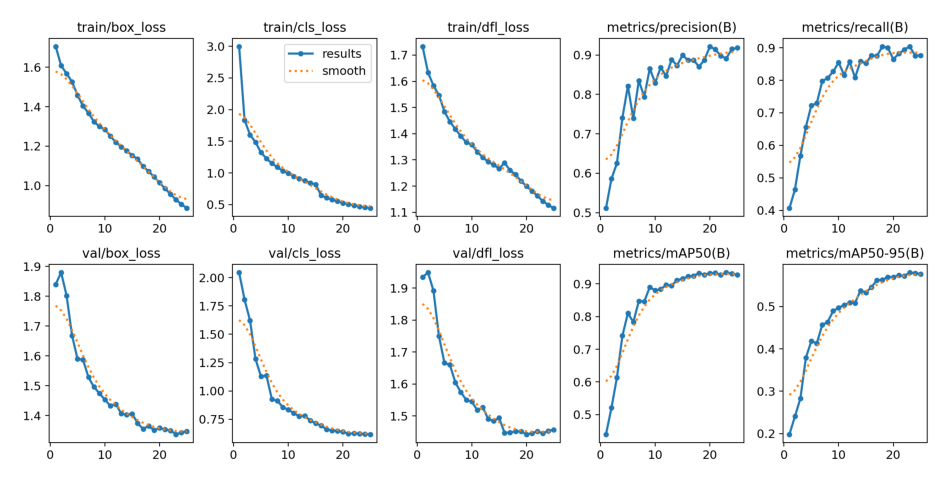

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Ruta de la imagen de resultados en Drive
results_path = os.path.join(DRIVE_PATH, 'driver_behaviour_train/results.png')

if os.path.exists(results_path):
    img = cv2.imread(results_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("La imagen de resultados aún no se ha generado.")

# Guardar los pesos del modelo entrenado

In [ ]:
import shutil

# Ruta de origen (donde YOLO guarda por defecto dentro de la carpeta del proyecto)
source_best = os.path.join(DRIVE_PATH, 'driver_behaviour_train/weights/best.pt')
# Destino final
final_destination = os.path.join(WEIGHTS_DESTINATION, 'driver_behaviour_v1.pt')

if os.path.exists(source_best):
    shutil.copy(source_best, final_destination)
    print(f"✅ Modelo guardado permanentemente en: {final_destination}")
else:
    print("❌ No se encontró el archivo de pesos.")

✅ Modelo guardado permanentemente en: /content/drive/MyDrive/Driver_Behaviour_Project/weights/driver_behaviour_v1.pt


# Continuar el entrenamiento hasta la epoca 50

In [ ]:
from ultralytics import YOLO
import os

# 1. Cargamos el modelo (usamos el 'last.pt' como punto de partida)
LAST_MODEL_PATH = '/content/drive/MyDrive/Driver_Behaviour_Project/driver_behaviour_train/weights/last.pt'

if os.path.exists(LAST_MODEL_PATH):
    model = YOLO(LAST_MODEL_PATH)

    # 2. Iniciamos un entrenamiento nuevo basado en ese modelo
    # IMPORTANTE: Aquí NO usamos resume=True.
    # Como ya hiciste 25, entrenaremos por otras 25 para completar las 50.
    model.train(
        data=f"{dataset.location}/data.yaml", # Necesitamos pasarle los datos de nuevo
        epochs=25,                            # Entrenamos las 25 que faltan
        imgsz=640,
        project='/content/drive/MyDrive/Driver_Behaviour_Project',
        name='driver_behaviour_train_final'   # Se guardará en una carpeta nueva para no confundirse
    )
else:
    print("❌ No se encontró el archivo 'last.pt' en Drive.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PTA-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Driver_Behaviour_Project/driver_behaviour_train/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=driver_behaviour_train_final, nbs=64, nms=Fa